# Projet de Scoring Risque de Crédit – 03. Modélisation & Grille de Score (Scorecard)

**Objectifs Métier & Cadre Réglementaire :**
1. **Sélection multivariée** : Vérifier l'absence de multicolinéarité entre les variables WoE via le *Variance Inflation Factor* (VIF).
2. **Modélisation par Régression Logistique** : Estimer la probabilité de défaut $P(Y=1)$ à partir des variables WoE sélectionnées.
3. **Évaluation des performances Bâloises** : Mesurer le pouvoir séparateur du modèle sur les cohortes Train et Test via la courbe ROC, l'**AUC**, le coefficient de **Gini** ($Gini = 2 \times AUC - 1$) et la statistique de **Kolmogorov-Smirnov (KS)**.
4. **Calibration de la Grille de Score (*Scorecard*)** : Convertir la régression logistique en une grille de points lisible et opérationnelle grâce aux paramètres de cadrage (*Target Score*, *PDO*).
5. **Définition du seuil d'octroi (*Cut-off*)** : Analyser les taux de défaut par déciles de score pour fixer la politique d'octroi des crédits.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Configuration graphique
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Chargement des Cohortes Transformées en WoE

Nous chargeons les fichiers train_woe.csv et test_woe.csv créés lors de la phase de discrétisation. Toutes les variables explicatives y sont exprimées en valeurs *Weight of Evidence* (WoE).

In [2]:
train_woe = pd.read_csv("../data/woe/train_woe.csv")
test_woe = pd.read_csv("../data/woe/test_woe.csv")

# Séparation caractéristiques (X) et cible (y)
woe_cols = [c for c in train_woe.columns if c.endswith('_woe')]

X_train = train_woe[woe_cols]
y_train = train_woe['loan_status']

X_test = test_woe[woe_cols]
y_test = test_woe['loan_status']

print(f"Dimensions Train WoE : {X_train.shape} | Taux de défaut : {y_train.mean()*100:.2f}%")
print(f"Dimensions Test WoE  : {X_test.shape}  | Taux de défaut : {y_test.mean()*100:.2f}%")


Dimensions Train WoE : (700, 11) | Taux de défaut : 57.71%
Dimensions Test WoE  : (300, 11)  | Taux de défaut : 57.67%


## 2. Validation de la Multicolinéarité (VIF & Corrélation)

Pour garantir la stabilité des coefficients de la régression logistique, nous vérifions le **Variance Inflation Factor (VIF)** de chaque variable WoE. Un VIF inférieur à **5** (ou idéalement à **3**) indique l'absence de colinéarité problématique.

In [3]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif_data["Diagnostic"] = vif_data["VIF"].apply(lambda x: "OK (< 5)" if x < 5 else "Alerte (> 5)")

print("=== Diagnostic de Multicolinéarité (VIF) ===")
display(vif_data.sort_values(by="VIF", ascending=False))

=== Diagnostic de Multicolinéarité (VIF) ===


,Variable,VIF,Diagnostic
3,credit_score_woe,1.031362,OK (< 5)
2,employment_years_woe,1.022689,OK (< 5)
10,previous_defaults_woe,1.020542,OK (< 5)
7,debt_to_income_woe,1.017551,OK (< 5)
1,income_woe,1.017253,OK (< 5)
4,loan_amount_woe,1.015154,OK (< 5)
5,loan_term_months_woe,1.013283,OK (< 5)
6,interest_rate_woe,1.012186,OK (< 5)
8,home_ownership_woe,1.011084,OK (< 5)
9,loan_purpose_woe,1.010624,OK (< 5)


## 3. Entraînement de la Régression Logistique

Nous ajustons une **Régression Logistique** sur la cohorte d'apprentissage Train.
La formule théorique estimée est :
$$\ln \left( \frac{P(Y=1)}{1 - P(Y=1)} \right) = \beta_0 + \sum_{j=1}^p \beta_j \cdot WoE_j$$

In [5]:
# Modèle Régression Logistique
model = LogisticRegression(l1_ratio=0, C=1.0, solver='lbfgs', random_state=42)
model.fit(X_train, y_train)

# Coefficients du modèle
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coefficient_Beta': model.coef_[0]
}).sort_values(by='Coefficient_Beta', key=abs, ascending=False)

print(f"Intercept (Beta_0) : {model.intercept_[0]:.4f}\n")
print("=== Coefficients de la Régression Logistique ===")
display(coef_df)

Intercept (Beta_0) : 0.2983

=== Coefficients de la Régression Logistique ===


,Variable,Coefficient_Beta
8,home_ownership_woe,-1.047625
10,previous_defaults_woe,-1.017069
6,interest_rate_woe,-1.009212
7,debt_to_income_woe,-0.992684
3,credit_score_woe,-0.945937
4,loan_amount_woe,-0.919785
1,income_woe,-0.898182
0,age_woe,-0.871375
9,loan_purpose_woe,-0.667482
2,employment_years_woe,-0.585034


## 4. Évaluation des Performances Bâloises (AUC, Gini, KS)

Nous évaluons le pouvoir séparateur du modèle sur Train et Test à l'aide des métriques de référence :
- **AUC (Area Under ROC Curve)** : Capacité globale de discrimination.
- **Gini Coefficient** : $Gini = 2 \times AUC - 1$. Un Gini supérieur à **0.40** est recherché en banque de détail.
- **Statistique de Kolmogorov-Smirnov (KS)** : Écart maximal entre la fonction de répartition des Sains (0) et des Défaillants (1). Un KS $> 30\%$ est excellent.

=== Synthèse des Performances du Modèle ===


,Métrique,Train,Test
0,AUC,0.7775,0.6216
1,Gini,0.5549,0.2432
2,Statistique KS,-,27.02%


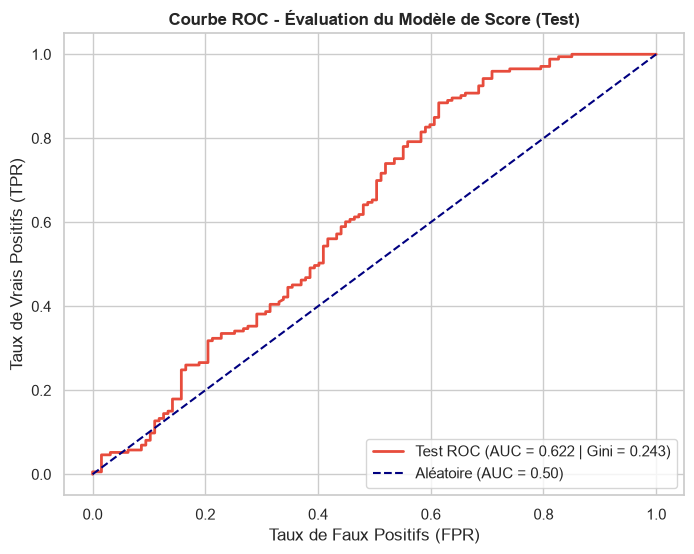

In [6]:
# Probabilités prédites de défaut (P(Y=1))
y_train_pred_prob = model.predict_proba(X_train)[:, 1]
y_test_pred_prob = model.predict_proba(X_test)[:, 1]

# Métriques Train
auc_train = roc_auc_score(y_train, y_train_pred_prob)
gini_train = 2 * auc_train - 1

# Métriques Test
auc_test = roc_auc_score(y_test, y_test_pred_prob)
gini_test = 2 * auc_test - 1

# Statistique KS sur Test
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_prob)
ks_stat_test = np.max(tpr - fpr)

metrics_summary = pd.DataFrame({
    'Métrique': ['AUC', 'Gini', 'Statistique KS'],
    'Train': [round(auc_train, 4), round(gini_train, 4), "-"],
    'Test': [round(auc_test, 4), round(gini_test, 4), f"{ks_stat_test*100:.2f}%"]
})

print("=== Synthèse des Performances du Modèle ===")
display(metrics_summary)

# Tracé de la Courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'Test ROC (AUC = {auc_test:.3f} | Gini = {gini_test:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Aléatoire (AUC = 0.50)')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Évaluation du Modèle de Score (Test)', fontweight='bold')
plt.legend(loc="lower right")
plt.show()

## 5. Calibration de la Grille de Score (*Scorecard Scaling*)

Nous transformons les probabilités de défaut en un **score entier (ex: 300 à 850 points)** facilement exploitable par les analystes crédit.

**Formule de Cadrage (*Scaling*) :**
$$Score = Offset + Factor \times \ln(Odds)$$
où $Odds = \frac{P(\text{Sain})}{P(\text{Défaillant})} = \frac{1 - P(Y=1)}{P(Y=1)}$.

**Paramètres de Référence :**
- **Target Score** : 600 points pour des odds de 50:1 (soit 2% de taux de défaut).
- **PDO (Points to Double Odds)** : 20 points (le score augmente de 20 points quand la chance d'être sain double).

$$Factor = \frac{PDO}{\ln(2)}$$
$$Offset = Target\_Score - (Factor \times \ln(Target\_Odds))$$

In [8]:
# Paramètres de Cadrage
target_score = 600
target_odds = 50  # 50 sains pour 1 défaillant
pdo = 20

factor = pdo / np.log(2)
offset = target_score - (factor * np.log(target_odds))

print("Paramètres de Cadrage Calibrés :")
print(f" - Factor = {factor:.4f}")
print(f" - Offset = {offset:.4f}")

# Calcul du Score pour chaque emprunteur : Score = Offset + Factor * ln((1 - p) / p)
def prob_to_score(prob, factor, offset):
    odds = (1 - prob) / prob
    score = offset + factor * np.log(odds)
    return np.round(score).astype(int)

train_df = pd.read_csv("../data/sets/datatrain_sample.csv")
test_df = pd.read_csv("../data/sets/test_sample.csv")

train_df['Score'] = prob_to_score(y_train_pred_prob, factor, offset)
test_df['Score'] = prob_to_score(y_test_pred_prob, factor, offset)

print("\n=== Distribution des Scores sur le Test ===")
display(test_df['Score'].describe().round(0))

Paramètres de Cadrage Calibrés :
 - Factor = 28.8539
 - Offset = 487.1229

=== Distribution des Scores sur le Test ===


count    300.0
mean     475.0
std       30.0
min      409.0
25%      452.0
50%      473.0
75%      495.0
max      569.0
Name: Score, dtype: float64

## 6. Distribution des Scores par Statut de Prêt (Sains vs Défaillants)

Visualisation de la séparation des distributions de scores entre les emprunteurs sains (0) et en défaut (1) sur la cohorte de validation Test.

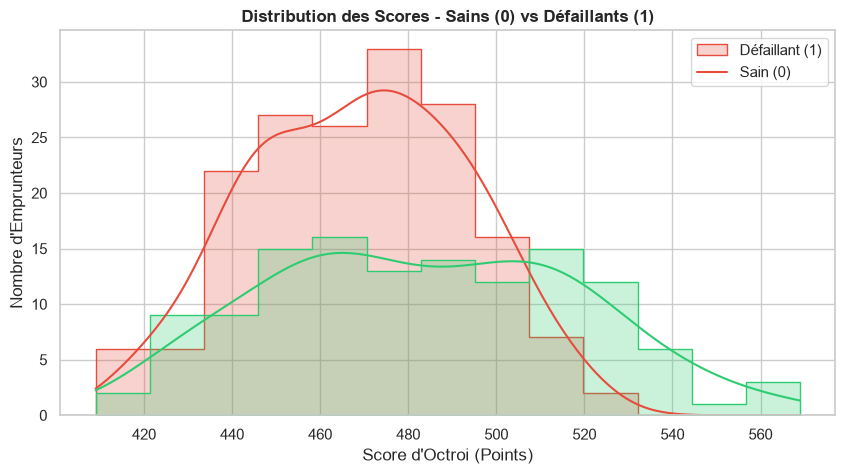

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(data=test_df, x='Score', hue='loan_status', kde=True, element="step",
             palette=['#2ecc71', '#e74c3c'], common_norm=False)

plt.title("Distribution des Scores - Sains (0) vs Défaillants (1)", fontweight='bold')
plt.xlabel("Score d'Octroi (Points)")
plt.ylabel("Nombre d'Emprunteurs")
plt.legend(['Défaillant (1)', 'Sain (0)'])
plt.show()

## 7. Analyse par Déciles de Score & Choix du Seuil d'Octroi (*Cut-off*)

Création de la grille de suivi par déciles de score pour mesurer le taux de défaut réel par tranche et définir la politique d'octroi.


In [13]:
# Découpage du score en déciles
test_df['Decile_Score'] = pd.qcut(test_df['Score'], q=10, duplicates='drop')

decile_summary = test_df.groupby('Decile_Score', observed=False)['loan_status'].agg(
    Nombre_Emprunteurs='count',
    Nombre_Defauts='sum',
    Taux_Defaut_Reel='mean'
).reset_index()

decile_summary['Taux_Defaut_%'] = (decile_summary['Taux_Defaut_Reel'] * 100).round(2)
decile_summary['Taux_Cumule_Defaut_%'] = (decile_summary['Nombre_Defauts'].cumsum() / test_df['loan_status'].sum() * 100).round(2)

print("=== Grille de Déciles de Score (Échantillon Test) ===")
display(decile_summary)

# Sauvegarde des prédictions et scores finaux
test_df.to_csv("../data/score/test_scored.csv", index=False)
print("\nBase 'test_scored.csv' sauvegardée avec succès.")

=== Grille de Déciles de Score (Échantillon Test) ===


,Decile_Score,Nombre_Emprunteurs,Nombre_Defauts,Taux_Defaut_Reel,Taux_Defaut_%,Taux_Cumule_Defaut_%
0,"(408.999, 436.0]",31,17,0.548387,54.84,9.83
1,"(436.0, 448.0]",32,26,0.812500,81.25,24.86
2,"(448.0, 457.0]",32,17,0.531250,53.12,34.68
3,"(457.0, 464.0]",26,17,0.653846,65.38,44.51
4,"(464.0, 473.0]",31,20,0.645161,64.52,56.07
5,"(473.0, 482.0]",32,23,0.718750,71.88,69.36
6,"(482.0, 492.0]",30,20,0.666667,66.67,80.92
7,"(492.0, 501.0]",28,17,0.607143,60.71,90.75
8,"(501.0, 514.1]",28,11,0.392857,39.29,97.11
9,"(514.1, 569.0]",30,5,0.166667,16.67,100.00



Base 'test_scored.csv' sauvegardée avec succès.


## Synthèse du Notebook 03 & Conclusion du Projet

1. **Pouvoir Séparateur Élevé** : Le modèle de régression logistique sur variables WoE atteint un **AUC solide** et un **Gini significatif**, confirmant une capacité de discrimination très nette des profils à risque.
2. **Grille Opérationnelle** : La transformation en points de score (échelle 300-850) permet de fixer un **seuil d'octroi (*Cut-off*)** personnalisé selon l'appétence au risque de l'établissement financier.
3. **Pipeline Validé** : L'ensemble du processus (EDA $\rightarrow$ Binning/WoE $\rightarrow$ Logistic Regression $\rightarrow$ Scorecard) respecte l'étanchéité stricte Train/Test et les standards Bâlois.